# Creating subsets of ABCD subjects for expert raters

This is for the Siemens data

In [ ]:
import json
import os
from pathlib import Path

import pandas as pd
import numpy as np

config_candidates = [
    os.environ.get("CONFIG_PATH", ""),
    "config.json",
    "../config.json",
    "../../config.json",
    "../../../config.json",
]
config_path = next(
    (Path(p).expanduser().resolve() for p in config_candidates if p and Path(p).expanduser().exists()),
    None
)
if config_path is None:
    raise FileNotFoundError("Could not find config.json. Set CONFIG_PATH or run from the project tree.")

config = json.loads(config_path.read_text())
project_root = Path(config["project_root"]).expanduser().resolve()

data_candidates = [
    project_root / "data" / "raw_data" / "merged_data_meisler_analyses_with_predictions.parquet",
    project_root / "data" / "raw_data" / "merged_data_meisler_analyses.parquet",
]
data_path = next((p for p in data_candidates if p.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        "Could not find merged data parquet in data/raw_data. Expected one of: "
        + ", ".join(str(p) for p in data_candidates)
    )

whole_qc_df = pd.read_parquet(data_path)
if "Manufacturer" not in whole_qc_df.columns and "scanner_manufacturer" in whole_qc_df.columns:
    whole_qc_df["Manufacturer"] = whole_qc_df["scanner_manufacturer"]

print(f"Loaded {data_path}")
print(whole_qc_df.shape)


(29561, 4337)


In [19]:
# Limit to baseline Siemens sessions
whole_qc_df = whole_qc_df[whole_qc_df.raw_num_directions > 101]
whole_qc_df = whole_qc_df[whole_qc_df.Manufacturer == "Siemens"]
whole_qc_df = whole_qc_df[whole_qc_df.session_id == "ses-00A"]

total_participants_original = whole_qc_df.shape[0]
print(whole_qc_df.shape)

(5685, 4337)


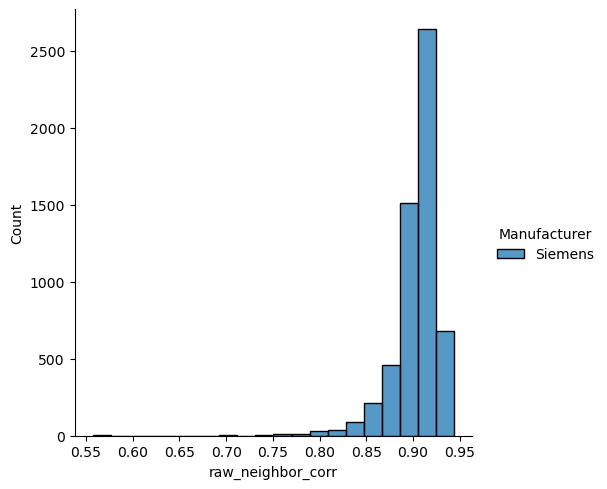

In [ ]:
# Plot the raw neighbor correlation histogram
import seaborn as sns
sns.displot(
    data=whole_qc_df, 
    x='raw_neighbor_corr', 
    hue="Manufacturer", 
    stat='count', 
    multiple='stack', 
    legend = True, bins=20)


In [22]:
# Convert the raw neighbor correlation to a rank
whole_qc_df['ManufacturerNDCRank'] = whole_qc_df.groupby("Manufacturer")[
    "raw_neighbor_corr"].rank(pct=True)
whole_qc_df.groupby("Manufacturer")['ManufacturerNDCRank'].max()

Manufacturer
Siemens    1.0
Name: ManufacturerNDCRank, dtype: float64

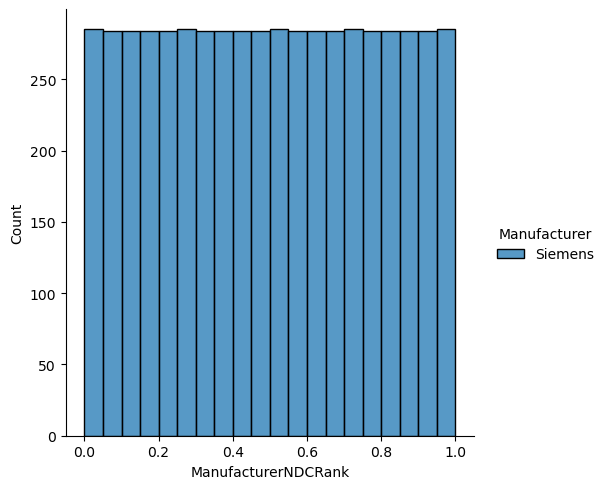

In [8]:
sns.displot(
    data=whole_qc_df, 
    x='ManufacturerNDCRank', 
    hue="Manufacturer", 
    stat='count', 
    multiple='stack', 
    legend = True, bins=20);

In [ ]:
# Create percentile bins of the raw neighbor correlation
def bin_percentiles(num_bins=10):
     return np.ceil(whole_qc_df["ManufacturerNDCRank"] * num_bins).astype(np.int32)

In [20]:
from collections import defaultdict
from tqdm import tqdm 
from random import shuffle
from math import comb
import itertools

def assign_subjects_to_raters(n_raters, n_raters_per_participant, n_ndc_bins, final_min_per_bin=1):
    total_n_participants = comb(n_raters, n_raters_per_participant)
    total_n_ratings = n_raters_per_participant * total_n_participants
    total_ratings_per_rater = total_n_ratings / n_raters
    subsample_percent = total_n_participants / total_participants_original
    
    print("Total number of ABCD subjects:", total_n_participants)
    print("Total number of ratings:", total_n_ratings)
    print("Total ratings per rater:", total_ratings_per_rater)
    print("Percent of total sample rated:", subsample_percent)
    
    # Prepare the rater matchings
    raters = list(range(n_raters))
    rater_combos = list(itertools.combinations(raters, 3))
    shuffle(rater_combos)
    
    # Prepare the dataset for subsetting
    qc_df = whole_qc_df.copy()
    qc_df["NDCBin"] = bin_percentiles(n_ndc_bins)
    
    mfg_counts_df = qc_df["Manufacturer"].value_counts(
        ).rename_axis('Manufacturer').reset_index(name='Count')
    mfg_counts_df["SubsetCount"] = np.ceil(mfg_counts_df["Count"] * subsample_percent).astype(np.int32)
    mfg_counts_df["CountPerNDCBin"] = np.ceil(mfg_counts_df["SubsetCount"] / n_ndc_bins).astype(np.int32)

    minima = {row.Manufacturer: row.CountPerNDCBin for _, row in mfg_counts_df.iterrows()}
    mfg_bins = list(itertools.product(mfg_counts_df["Manufacturer"], range(1, n_ndc_bins+1)))
   
    counts_df = qc_df[["Manufacturer", "NDCBin"]].value_counts().reset_index()
    counts_df.columns = ["Manufacturer", "NDCBin", "NParticipants"]
    counts_df.sort_values(["Manufacturer", "NDCBin"], inplace=True)
    
    # Holds assignments
    selected_subjects = []
    rater_assignments = {rater: {key: [] for key in mfg_bins} for rater in raters}
    bin_assignments = pd.DataFrame(
        np.zeros((len(raters), len(mfg_bins))), index=raters, 
        columns=[f"{mfg}_{binn}" for mfg, binn in mfg_bins])
    needs_assignment = []
    
    def assign_to_rater(rater_id, subject_id, manufacturer, ndcbin):
        rater_assignments[rater_id][(manufacturer,ndcbin)].append(subid)
        col = f"{manufacturer}_{ndcbin}"
        bin_assignments.loc[rater_id, col] += 1
        selected_subjects.append(subject_id)
    
    for manufacturer, mfg_df in counts_df.groupby("Manufacturer"):
        mfg_bin_min = mfg_df["NParticipants"].min()
        if mfg_bin_min < minima[manufacturer]:
            raise Exception("Not enough particpants in each bin for " + manufacturer)

        # Get the subjects for each bin
        for ndcbin, ndcbin_df in qc_df[qc_df["Manufacturer"]==manufacturer].groupby("NDCBin"):
            inbin_subjects = ndcbin_df.sample(n=minima[manufacturer], replace=False)
            
            # Assign each subject to 3 raters
            for subid in inbin_subjects['subject_id'].tolist():
                if len(rater_combos):
                    for rater_id in rater_combos.pop():
                        assign_to_rater(rater_id, subid, manufacturer, ndcbin)
                else:
                    needs_assignment.append((manufacturer, ndcbin, subid))
        
        
    # Assing everyone leftover to 3 raters each
    rater_combos = list(itertools.combinations(raters, 3))
    shuffle(rater_combos)
    for (manufacturer, ndcbin, subid) in needs_assignment:
        for rater_id in rater_combos.pop():
            assign_to_rater(rater_id, subid, manufacturer, ndcbin)

    n_fillers = 0
    if bin_assignments.min().min() < final_min_per_bin:
        print("adding subjects to fit minimum")
        
        needed_rows, needed_cols = np.nonzero((bin_assignments < final_min_per_bin).to_numpy())
        n_fillers = len(needed_rows)
        for needed_row, needed_col in zip(needed_rows, needed_cols):
            unassigned_subjects = qc_df[
                np.logical_not(qc_df["subject_id"].isin(selected_subjects))]
            rater_id = raters[needed_row]
            mfg, binn = bin_assignments.columns[needed_col].split("_")
            binn=int(binn)
            available_data = unassigned_subjects[
                (unassigned_subjects["Manufacturer"]==mfg) * (unassigned_subjects["NDCBin"]==binn)]
            assign_to_rater(rater_id, unassigned_subjects['subject_id'].tolist()[0], manufacturer, binn)
            
            
        
    return bin_assignments, rater_assignments, n_fillers
    

Now that we know things are stratified we can double-check that all the balancing has worked

In [23]:
n_raters = 23
bin_assignments, rater_assignments, n_fillers = assign_subjects_to_raters(n_raters, 3, 7, 2)

Total number of ABCD subjects: 1771
Total number of ratings: 5313
Total ratings per rater: 231.0
Percent of total sample rated: 0.31152154793315745


In [12]:
sub_to_rater = defaultdict(list)
rater_to_sub = defaultdict(list)

for rater, binned_assignments in rater_assignments.items():
    for binname, subids in binned_assignments.items():
        rater_to_sub[rater].extend(subids)
        for subid in subids:
            sub_to_rater[subid].append(rater)
        

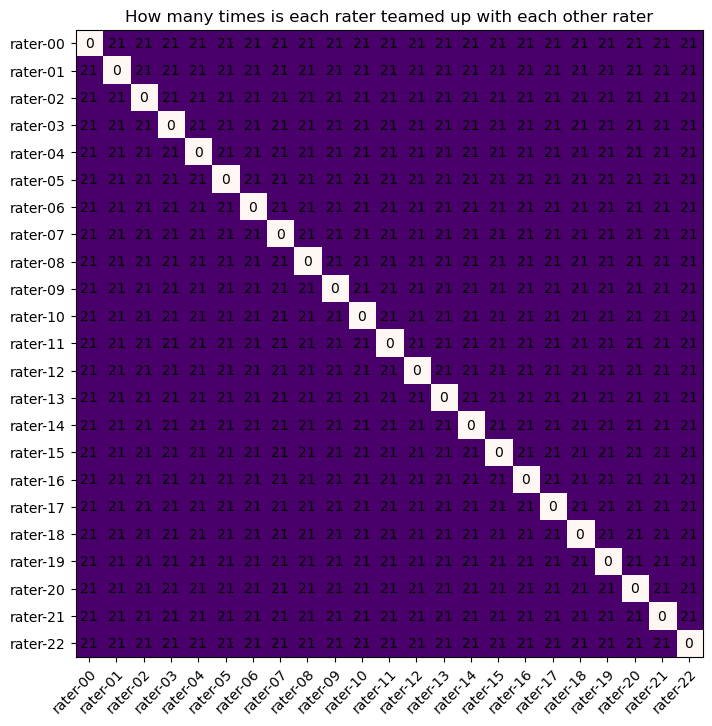

In [13]:
from matplotlib import pyplot as plt
raters = ["rater-%02d"%raternum for raternum in range(n_raters)]
irr_matrix = np.zeros((n_raters, n_raters))

for participant, rater_combo in sub_to_rater.items():
    for pair in itertools.permutations(rater_combo, 2):
        irr_matrix[pair] += 1

fig, ax = plt.subplots(figsize=(7, 7))
fig.tight_layout()

im = ax.imshow(irr_matrix, cmap="RdPu")

# Show all ticks and label them with the respective list entries
ax.set_xticks(np.arange(len(raters)), labels=raters)
ax.set_yticks(np.arange(len(raters)), labels=raters)

# Rotate the tick labels and set their alignment.
plt.setp(ax.get_xticklabels(), rotation=45, ha="right",
         rotation_mode="anchor")

# Loop over data dimensions and create text annotations.
for i in range(len(raters)):
    for j in range(len(raters)):
        text = ax.text(j, i, int(irr_matrix[i, j]),
                       ha="center", va="center", color="k")

_ = ax.set_title("How many times is each rater teamed up with each other rater")

# Get QC and Directories for each rater!

In [ ]:
import json
import os
import shutil
from pathlib import Path

results_dir_env = os.environ.get("QC_REPORTS_DIR", "").strip()
if not results_dir_env:
    raise ValueError("Set QC_REPORTS_DIR to the folder containing per-subject report directories.")

results_dir = Path(results_dir_env).expanduser().resolve()
if not results_dir.exists():
    raise FileNotFoundError(f"QC_REPORTS_DIR does not exist: {results_dir}")

output_dir = project_root / "data" / "quality_classifier" / "rater_subsets" / "siemens"
output_dir.mkdir(parents=True, exist_ok=True)


def generate_rater_bundle(subject_list, raternum, output_root):
    """
    Create a directory with all the files needed for a rater to do their rating
    """

    rater_subset = whole_qc_df[whole_qc_df["subject_id"].isin(subject_list)]

    for vendor_name, vendor_df in rater_subset.groupby("Manufacturer"):
        vendor_dir = output_root / vendor_name
        vendor_dir.mkdir(parents=True, exist_ok=True)

        subsample_csv = vendor_dir / ("rater-%02d_abcd_%s_subset.csv" % (raternum, vendor_name))
        vendor_df.to_csv(subsample_csv, index=False)

        report_errors = []
        qc_report = {
            "report_type": "dwi_qc_report",
            "pipeline": "qsiprep",
            "pipeline_version": 0,
            "boilerplate": "",
            "metric_explanation": {
                "raw_dimension_x": "Number of x voxels in raw images",
                "raw_dimension_y": "Number of y voxels in raw images",
                "raw_dimension_z": "Number of z voxels in raw images",
                "raw_voxel_size_x": "Voxel size in x direction in raw images",
                "raw_voxel_size_y": "Voxel size in y direction in raw images",
                "raw_voxel_size_z": "Voxel size in z direction in raw images",
                "raw_max_b": "Maximum b-value in s/mm^2 in raw images",
                "raw_neighbor_corr": "Neighboring DWI Correlation (NDC) of raw images",
                "raw_num_bad_slices": "Number of bad slices in raw images (from DSI Studio)",
                "raw_num_directions": "Number of directions sampled in raw images",
                "t1_dimension_x": "Number of x voxels in preprocessed images",
                "t1_dimension_y": "Number of y voxels in preprocessed images",
                "t1_dimension_z": "Number of z voxels in preprocessed images",
                "t1_voxel_size_x": "Voxel size in x direction in preprocessed images",
                "t1_voxel_size_y": "Voxel size in y direction in preprocessed images",
                "t1_voxel_size_z": "Voxel size in z direction in preprocessed images",
                "t1_max_b": "Maximum b-value s/mm^2 in preprocessed images",
                "t1_neighbor_corr": "Neighboring DWI Correlation (NDC) of preprocessed images",
                "t1_num_bad_slices": "Number of bad slices in preprocessed images (from DSI Studio)",
                "t1_num_directions": "Number of directions sampled in preprocessed images",
                "mean_fd": "Mean framewise displacement from head motion",
                "max_fd": "Maximum framewise displacement from head motion",
                "max_rotation": "Maximum rotation from head motion",
                "max_translation": "Maximum translation from head motion",
                "max_rel_rotation": "Maximum rotation relative to the previous head position",
                "max_rel_translation": "Maximum translation relative to the previous head position",
                "CNR0_mean": "Mean in-brain CNR for b=0",
                "CNR1_mean": "Mean in-brain CNR for b=500",
                "CNR2_mean": "Mean in-brain CNR for b=1000",
                "CNR3_mean": "Mean in-brain CNR for b=2000",
                "CNR4_mean": "Mean in-brain CNR for b=3000",
                "t1_dice_distance": "Dice score for the overlap of the T1w-based brain mask and the b=0 ref mask"
            }
        }
        qc_values = []

        for _, row in vendor_df.iterrows():
            row = dict(row)
            dwi_qc = {metric_name: row[metric_name] for metric_name in qc_report["metric_explanation"]}
            dwi_qc["participant_id"] = dwi_qc.get("subject_id", "subject")
            qc_values.append(dwi_qc)

        qc_report["subjects"] = qc_values

        with open(vendor_dir / "dwiqc.json", "w") as project_qc:
            json.dump(qc_report, project_qc, indent=2)

        for subid in vendor_df["subject_id"].tolist():
            subject_copy = vendor_dir / subid
            subject_copy.mkdir(parents=True, exist_ok=True)
            sub_dir = results_dir / subid
            if sub_dir.exists():
                shutil.copytree(sub_dir, subject_copy, dirs_exist_ok=True)
            else:
                report_errors.append(str(sub_dir))

        if report_errors:
            print(f"[WARN] Missing report dirs for {vendor_name}, rater {raternum}: {len(report_errors)}")


for raternum, assigned_subjects in tqdm(rater_to_sub.items()):
    output_root = output_dir / ("rater-%02d" % raternum)
    output_root.mkdir(parents=True, exist_ok=True)
    generate_rater_bundle(assigned_subjects, raternum, output_root)
